# 01 - Exploration

Objectif : regarder les données brutes d'UCI HAR avant tout traitement.
On vérifie les valeurs manquantes, les fenêtres dupliquées, l'équilibre des classes, et si le split train/test est déjà séparé par sujet (aucun sujet présent dans les deux ensembles).

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/raw/UCI HAR Dataset")

## Étiquettes des activités

In [2]:
activity_labels = pd.read_csv(DATA_DIR / "activity_labels.txt", sep=r"\s+", header=None, names=["id", "activity"])
activity_labels

,id,activity
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


## Sujets et identifiants d'activité

In [3]:
def load_ids(path):
    return pd.read_csv(path, header=None, names=["value"]).squeeze("columns")

subject_train = load_ids(DATA_DIR / "train" / "subject_train.txt")
subject_test = load_ids(DATA_DIR / "test" / "subject_test.txt")

y_train = load_ids(DATA_DIR / "train" / "y_train.txt")
y_test = load_ids(DATA_DIR / "test" / "y_test.txt")

print("train windows:", len(y_train))
print("test windows:", len(y_test))

train windows: 7352
test windows: 2947


## Split train / test par sujet

Les auteurs du dataset ont déjà séparé train et test par sujet. On le vérifie : aucun sujet ne doit apparaître dans les deux ensembles, sinon notre évaluation serait biaisée (le modèle pourrait en partie reconnaître la façon de bouger d'une personne plutôt que l'activité elle-même).

In [4]:
train_subjects = set(subject_train.unique())
test_subjects = set(subject_test.unique())

print("number of train subjects:", len(train_subjects))
print("number of test subjects:", len(test_subjects))
print("subjects in both sets:", train_subjects & test_subjects)

number of train subjects: 21
number of test subjects: 9
subjects in both sets: set()


## Valeurs manquantes et fenêtres dupliquées dans les signaux bruts

In [5]:
def load_signal(split, signal_name):
    path = DATA_DIR / split / "Inertial Signals" / f"{signal_name}_{split}.txt"
    return np.loadtxt(path)

signal_names = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

for name in signal_names:
    data = load_signal("train", name)
    n_missing = np.isnan(data).sum()
    n_duplicates = pd.DataFrame(data).duplicated().sum()
    print(f"{name:12s} shape={data.shape} missing={n_missing} duplicated_windows={n_duplicates}")

body_acc_x   shape=(7352, 128) missing=0 duplicated_windows=0


body_acc_y   shape=(7352, 128) missing=0 duplicated_windows=0


body_acc_z   shape=(7352, 128) missing=0 duplicated_windows=0


body_gyro_x  shape=(7352, 128) missing=0 duplicated_windows=0


body_gyro_y  shape=(7352, 128) missing=0 duplicated_windows=0


body_gyro_z  shape=(7352, 128) missing=0 duplicated_windows=0


total_acc_x  shape=(7352, 128) missing=0 duplicated_windows=0


total_acc_y  shape=(7352, 128) missing=0 duplicated_windows=0


total_acc_z  shape=(7352, 128) missing=0 duplicated_windows=0


## Répartition des classes (train vs test)

train:
 value
LAYING                1407
SITTING               1286
STANDING              1374
WALKING               1226
WALKING_DOWNSTAIRS     986
WALKING_UPSTAIRS      1073
Name: count, dtype: int64

test:
 value
LAYING                537
SITTING               491
STANDING              532
WALKING               496
WALKING_DOWNSTAIRS    420
WALKING_UPSTAIRS      471
Name: count, dtype: int64


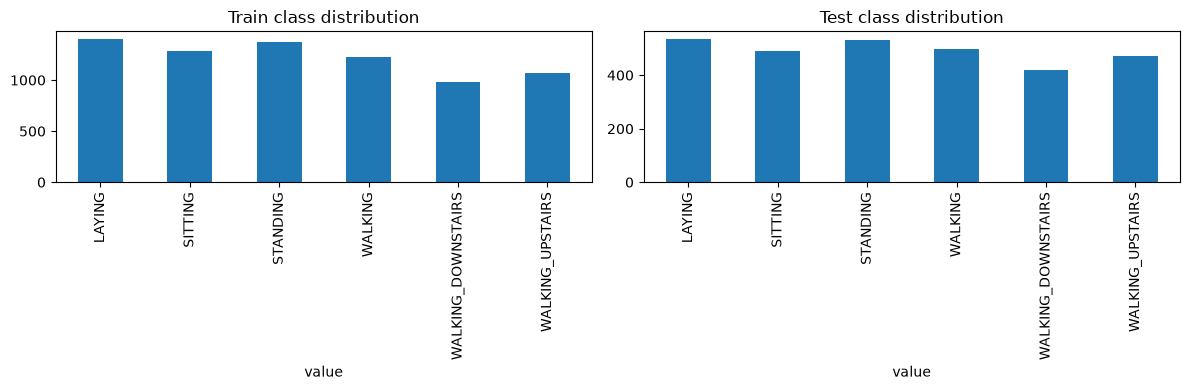

In [6]:
id_to_name = activity_labels.set_index("id")["activity"]

train_counts = y_train.map(id_to_name).value_counts().sort_index()
test_counts = y_test.map(id_to_name).value_counts().sort_index()

print("train:\n", train_counts)
print("\ntest:\n", test_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_counts.plot(kind="bar", ax=axes[0], title="Train class distribution")
test_counts.plot(kind="bar", ax=axes[1], title="Test class distribution")
plt.tight_layout()
plt.savefig("../results/class_distribution.png")
plt.show()

## Exemple de signal brut par classe

Une fenêtre de `total_acc_x` pour chaque activité, pour voir visuellement que les postures statiques (assis, debout, allongé) sont plus plates que les activités dynamiques (marche, escaliers).

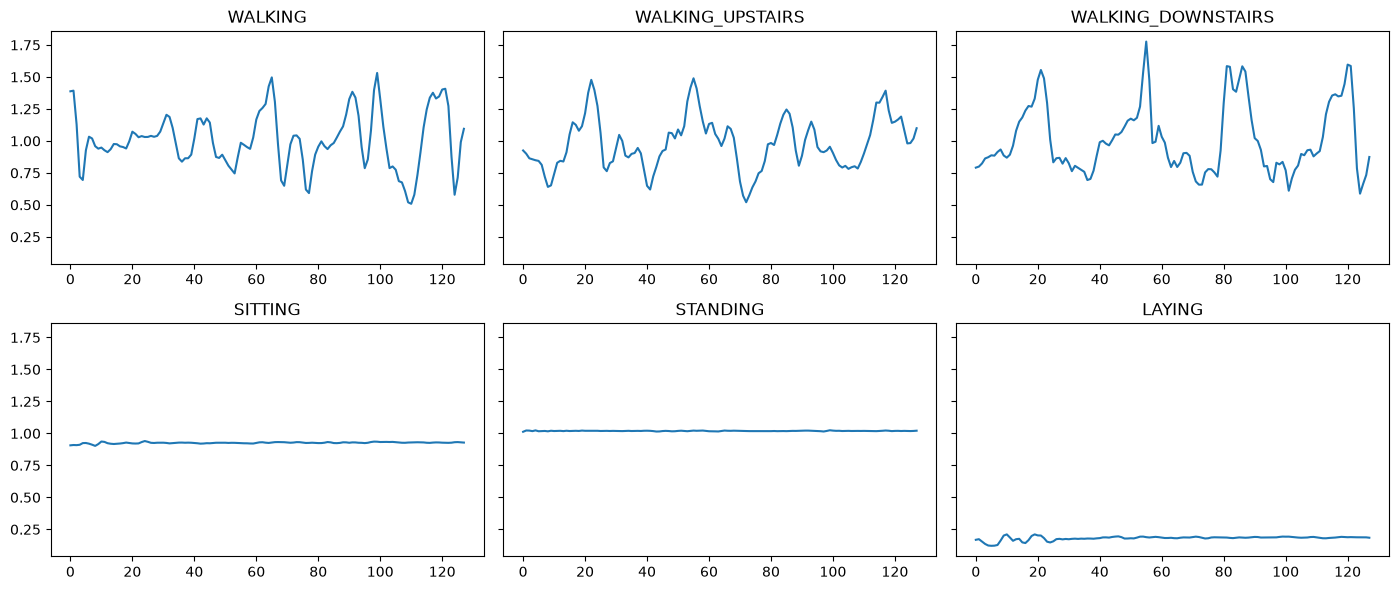

In [7]:
total_acc_x_train = load_signal("train", "total_acc_x")

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharey=True)
for ax, (activity_id, activity_name) in zip(axes.flat, id_to_name.items()):
    window_index = y_train[y_train == activity_id].index[0]
    ax.plot(total_acc_x_train[window_index])
    ax.set_title(activity_name)
plt.tight_layout()
plt.savefig("../results/example_signals_per_class.png")
plt.show()

## Observations

- **Split par sujet :** 21 sujets en train, 9 en test, zéro chevauchement entre les deux ensembles. Les auteurs du dataset ont déjà séparé les personnes entre train et test, donc un split aléatoire sur des fenêtres individuelles aurait été une erreur ici (ça aurait fait fuiter le signal d'une même personne à la fois dans le train et dans le test).
- **Valeurs manquantes :** aucune, sur aucun des 9 fichiers de signaux bruts (body acc, body gyro, total acc, x/y/z).
- **Fenêtres dupliquées :** aucune trouvée non plus. Les données sont propres, aucun nettoyage n'est nécessaire avant le fenêtrage/la normalisation.
- **Équilibre des classes :** le train va de 986 (WALKING_DOWNSTAIRS) à 1407 (LAYING) fenêtres, le test de 420 à 537. Ce n'est pas parfaitement équilibré mais pas extrême non plus (~1,4x entre la plus petite et la plus grande classe). C'est pour ça que l'accuracy seule ne suffira pas plus tard : un F1-score macro reflétera mieux la performance sur les classes plus petites comme WALKING_DOWNSTAIRS.
- **Signaux exemples :** les activités statiques (SITTING, STANDING, LAYING) sont visuellement plus plates et régulières que les activités dynamiques (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS), qui montrent un motif périodique clair. Ça confirme que le signal brut porte l'information nécessaire pour séparer les activités, et SITTING (~0,92g) et STANDING (~1,02g) sont particulièrement proches en amplitude, ce qui laisse penser qu'elles seront la paire la plus dure à distinguer pour le modèle. LAYING est plat aussi mais à un niveau bien plus bas (~0,2g) car la position allongée change l'axe qui fait face à la gravité.